# Notebook - Find best Drug compound for `Bacillus Anthracis` bacteria. This bacteria is responsible for anthrax disease.

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [2]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [3]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load
from PIL import Image
import pickle
import gc

sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [4]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [5]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
saveDir = os.path.join(resultsDir, "Bacillus_anthracis_bestMACAW/")
ARTresultsDir = os.path.join(dataDir, 'Results/Bacillus_anthracis_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

In [6]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM.csv')

In [7]:
allBacteriaData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family,pPotencyMid
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623413e+05,0.250000,True,MIC,0.250000
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,...,1.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-94,100.000000,True,MIC,100.000000
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,...,3.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162278e+04,1.500000,True,MIC,1.500000
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163417,313296,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,C12H25NS3,LGZOHACUFLJANX-UHFFFAOYSA-N,InChI=1S/C12H25NS3/c1-4-7-8-9-10-11-15-16-12(1...,279.54,Small molecule,32000.00,nM,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,3.200000e+01,4.494850,True,MIC,4.494850
163418,313298,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,C145H210N28O21,QNANZYFCKTWPTJ-WSPVJQGRSA-N,InChI=1S/C145H210N28O21/c1-93(174)154-76-36-65...,2681.45,Small molecule,46600.00,nM,...,NaN,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.660000e+01,4.331614,True,MIC,4.331614
163419,313304,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,C16H19N3O,XVNKQYMDQJGTEQ-UHFFFAOYSA-N,"InChI=1S/C16H19N3O/c1-16(2,13-6-4-3-5-7-13)11-...",269.35,NaN,256.00,ug.mL-1,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.000000e-250,256.000000,True,MIC,256.000000
163420,313309,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,C9H10N2OS2,SATLYQNFXURMCO-UXBLZVDNSA-N,InChI=1S/C9H10N2OS2/c1-14-9(13)11-10-6-7-4-2-3...,226.33,Small molecule,4000.00,nM,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.000000e+00,5.397940,True,IC/EC,5.397940


### Filter columns

In [8]:
allBacteriaData_chEMBL = allBacteriaData_chEMBL.rename(
    columns={'Virus': 'Bacteria'})
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Bacteria"]
)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Bacteria
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestisData_chEMBL_combined.csv
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestisData_chEMBL_combined.csv
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestisData_chEMBL_combined.csv
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestisData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Bacteria' column

In [9]:
allBacteriaData_chEMBL['Bacteria'] = allBacteriaData_chEMBL['Bacteria'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL.rename(columns={'Bacteria': 'BacteriaClassifier'}, inplace=True)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestis


### Keep only data for `Bacillus_anthracis` bacteria

In [10]:
BacillusAnthracisData_chEMBL = allBacteriaData_chEMBL[allBacteriaData_chEMBL['BacteriaClassifier'] == 'Bacillus_anthracis']
BacillusAnthracisData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,7.585776e+05,0.12,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,1.000000e+04,2.00,Bacillus_anthracis
...,...,...,...,...,...
163230,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,1.000000e+01,5.00,Bacillus_anthracis
163231,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],1.000000e-44,50.00,Bacillus_anthracis
163232,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,1.000000e-194,200.00,Bacillus_anthracis
163233,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,1.584893e-02,7.80,Bacillus_anthracis


### Remove `Basidalin` from training set

In [11]:
#Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Basidalin_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
BacillusAnthracisData_chEMBL["canonical_smiles"] = (
    BacillusAnthracisData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = BacillusAnthracisData_chEMBL["canonical_smiles"] != remCan
BacillusAnthracisData_chEMBL_clean = BacillusAnthracisData_chEMBL[mask].copy()

print("Original shape of data frame:", len(BacillusAnthracisData_chEMBL))
print("After removing Basidalin:", len(BacillusAnthracisData_chEMBL_clean))
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL_clean.copy()

Original shape of data frame: 856
After removing Basidalin: 856


### Rename columns

In [12]:
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    #"pPotencyMid" : "pPotency",
})
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.filter(
    items=["compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
BacillusAnthracisData_chEMBL.head()

,compound_id,Smiles,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00,Bacillus_anthracis


### Add `ID` column to left; keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [13]:
BacillusAnthracisData_chEMBL.insert(0, 'ID', range(1, len(BacillusAnthracisData_chEMBL) + 1))
BacillusAnthracisData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
162379,1,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12,Bacillus_anthracis
162380,2,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162381,3,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162382,4,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00,Bacillus_anthracis
162383,5,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00,Bacillus_anthracis


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [14]:
print("Original shape:", BacillusAnthracisData_chEMBL.shape)

BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL[BacillusAnthracisData_chEMBL['pPotency'].notna() 
    & (BacillusAnthracisData_chEMBL['pPotency'] > 0) & (BacillusAnthracisData_chEMBL['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", BacillusAnthracisData_chEMBL.shape)

Original shape: (856, 5)
Shape after cleaning 'pPotency' value: (672, 5)


In [15]:
duplicates = BacillusAnthracisData_chEMBL.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 274


In [16]:
BacillusAnthracisData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MLready.csv"), index=False)

### Create MACAW embeedings to run ART

In [17]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=60, 
    n_landmarks=600, 
    random_state=42
)


# Fit MACAW on SMILES and pPotency
mcw.fit(BacillusAnthracisData_chEMBL['Smiles'], BacillusAnthracisData_chEMBL['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracisData_chEMBL['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracisData_chEMBL.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
BacillusAnthracisData_chEMBL_wMACAW = pd.concat([BacillusAnthracisData_chEMBL, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracisData_chEMBL.shape}")
print(f"New dataframe shape: {BacillusAnthracisData_chEMBL_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracisData_chEMBL_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (672, 60)

Original dataframe shape: (672, 5)
New dataframe shape: (672, 65)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_60']


,ID,compound_id,Smiles,pPotency,BacteriaClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
162379,1,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.120000,Bacillus_anthracis,-0.018652,-0.100453,0.105430,-0.081585,0.161070,...,0.065073,-0.020712,-0.026059,-0.114491,-0.017395,0.000690,-0.017051,-0.014599,0.024146,0.010576
162380,2,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis,0.046998,-0.122113,0.428176,-0.148836,0.025848,...,0.003626,-0.013665,0.007502,0.015258,-0.051508,0.033997,0.029258,0.011617,0.009726,-0.073173
162381,3,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis,0.046998,-0.122113,0.428176,-0.148836,0.025848,...,0.003626,-0.013665,0.007502,0.015258,-0.051508,0.033997,0.029258,0.011617,0.009726,-0.073173
162382,4,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.000000,Bacillus_anthracis,0.046998,-0.122113,0.428176,-0.148836,0.025848,...,0.003626,-0.013665,0.007502,0.015258,-0.051508,0.033997,0.029258,0.011617,0.009726,-0.073173
162383,5,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.000000,Bacillus_anthracis,-0.370511,-0.099606,-0.016097,-0.051336,-0.034451,...,0.028469,-0.028273,0.002022,-0.040232,0.041230,-0.015788,-0.087387,-0.051552,-0.035481,0.040050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163227,849,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,Bacillus_anthracis,-0.014473,0.186074,0.040162,-0.045755,0.112505,...,-0.013555,0.009093,0.036995,0.000859,0.008753,-0.011372,-0.034202,0.010265,-0.031631,0.074735
163229,851,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,Bacillus_anthracis,0.054323,0.016792,0.073347,-0.027284,0.036792,...,-0.095800,0.077082,0.026510,0.040045,0.118461,0.011765,-0.018809,0.018518,-0.032621,0.057416
163230,852,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,Bacillus_anthracis,0.153448,-0.027975,0.096126,-0.011554,-0.029038,...,0.025227,0.018775,-0.035349,0.010262,0.083991,0.039346,-0.078559,-0.059014,-0.114464,0.080811
163233,855,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,Bacillus_anthracis,0.143252,0.080518,0.085291,0.036010,-0.052764,...,0.096542,-0.009657,-0.082190,0.048606,0.037881,-0.046191,-0.043480,-0.006479,0.017838,-0.046839


In [18]:
BacillusAnthracisData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [238]:
# df = BacillusAnthracisData_chEMBL
Y = BacillusAnthracisData_chEMBL.pPotency
smiles = BacillusAnthracisData_chEMBL.Smiles

In [239]:
print(len(smiles))

672


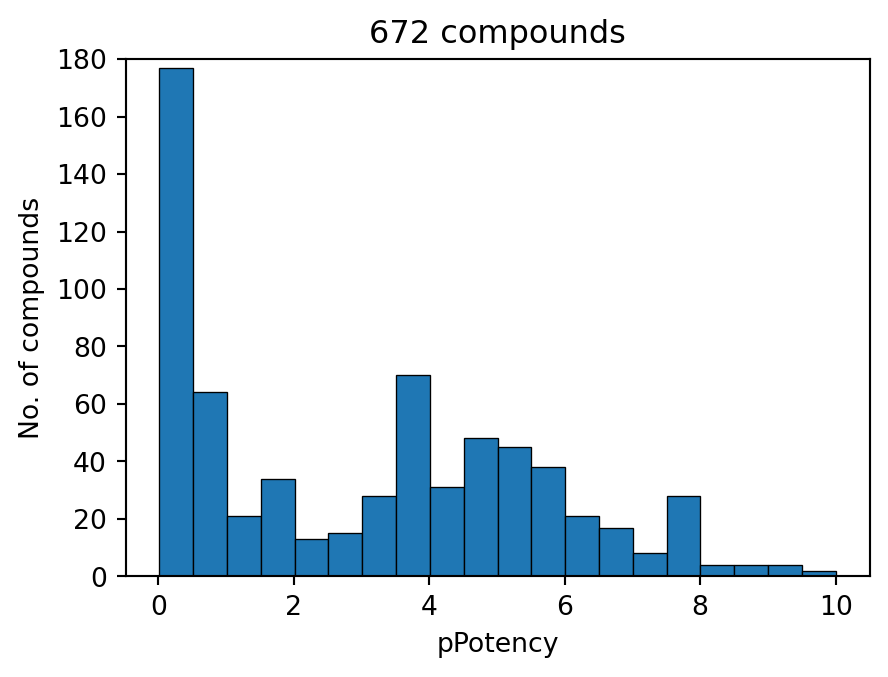

In [240]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [241]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [242]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [243]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=60, 
    n_landmarks=600, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [244]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True) 


print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 672 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [245]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  1.18
  RMSE: 1.63
  R²:   0.59
Test Set:
  MAE:  1.42
  RMSE: 1.96
  R²:   0.42

Best params (sample): [{'C': 10, 'epsilon': 1, 'kernel': 'rbf'}, {'C': 7, 'epsilon': 1, 'kernel': 'rbf'}, {'C': 7, 'epsilon': 1, 'kernel': 'rbf'}]
CPU times: user 282 ms, sys: 78.8 ms, total: 361 ms
Wall time: 29.2 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW//BacillusAnthracis_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW//BacillusAnthracis_CV_TrTs.png


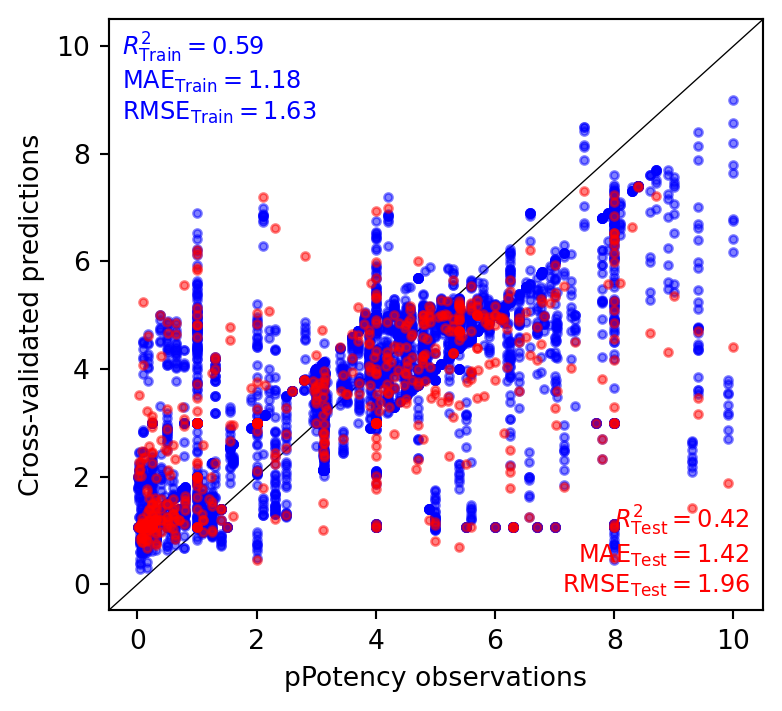

In [246]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/BacillusAnthracis_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

Training samples: 537
Test samples: 135
Feature dimensions: 100

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 10
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 1.18

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.67            0.18            0.49           
MAE        0.65            1.35            0.70           
RMSE       1.47            2.30            0.83           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW//BacillusAnthracis_fullData_TrTs.svg
Saved: /mnt/dat

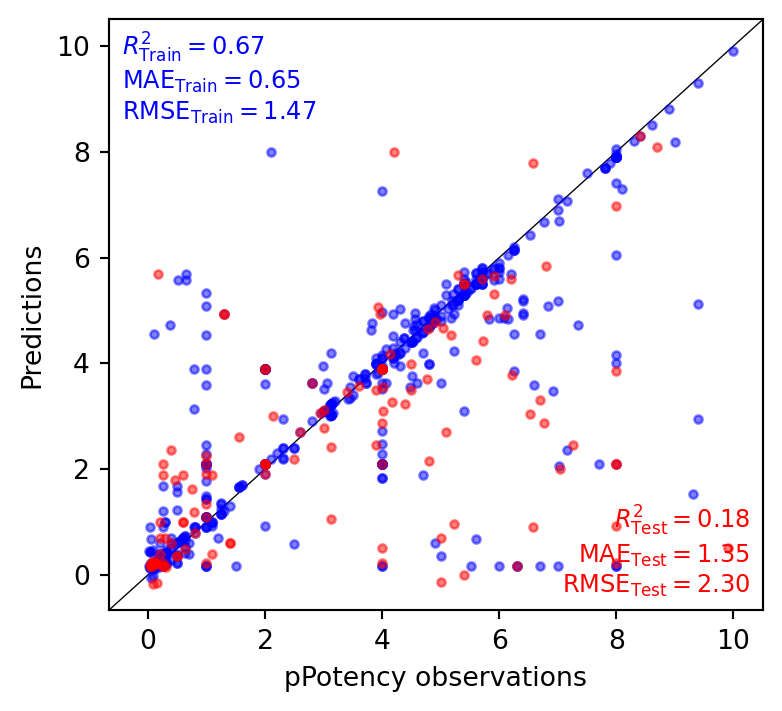

CPU times: user 3.51 s, sys: 80.5 ms, total: 3.59 s
Wall time: 5.39 s


In [247]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one Bacteria group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=100, 
    n_landmarks=500, 
    random_state=42
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)


# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/BacillusAnthracis_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

### Create a list of data frames of all buyable antibiotic

In [248]:
EnamineAntibioticData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibioticData.shape}")

smiles_train = BacillusAnthracisData_chEMBL.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibioticData['Canonical_SMILES'] = EnamineAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibioticData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibioticData_filtered = EnamineAntibioticData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibioticData = EnamineAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibioticData.shape}")
print(f"Removed {EnamineAntibioticData_filtered.shape[0] - EnamineAntibioticData.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntibioticData.SMILES
EnamineAntibioticData['source_DataBase'] = 'Enamine_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
EnamineAntibioticData = EnamineAntibioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntibioticData.head()

Original Enamine data shape: (32000, 11)
Number of unique SMILES in training set: 398
Filtered Enamine data shape for validation: (32000, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 32000


,SMILES,source_DataBase
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Enamine_Antibiotic
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Enamine_Antibiotic
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Enamine_Antibiotic
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Enamine_Antibiotic
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Enamine_Antibiotic


In [249]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibioticData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibioticData['Canonical_SMILES'] = LCAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibioticData['Canonical_SMILES'].isin(canonical_train)
LCAntibioticData_filtered = LCAntibioticData[mask].copy()

# Remove the helper column if you don't need it
LCAntibioticData = LCAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibioticData.shape}")
print(f"Removed {LCAntibioticData_filtered.shape[0] - LCAntibioticData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntibioticData = LCAntibioticData.SMILES
LCAntibioticData['source_DataBase'] = 'LifeChemicals_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
LCAntibioticData = LCAntibioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_LCAntibioticData)}")
LCAntibioticData.head()

Original LifeChemicals data shape: (15538, 26)
Number of unique SMILES in training set: 398
Filtered LifeChemicals data shape for validation: (15532, 26)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 15532


,SMILES,source_DataBase
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,LifeChemicals_Antibiotic
1,OC1CCCN(c2ncnc3c2CCCC3)C1,LifeChemicals_Antibiotic
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,LifeChemicals_Antibiotic
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,LifeChemicals_Antibiotic
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,LifeChemicals_Antibiotic


In [250]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiBioticData = ChemDivAntiBioticData.SMILES
ChemDivAntiBioticData['source_DataBase'] = 'ChemDiv_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
ChemDivAntiBioticData = ChemDivAntiBioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiBioticData)}")
ChemDivAntiBioticData

Original ChemDiv data shape: (12510, 16)
Number of unique SMILES in training set: 398
Filtered ChemDiv data shape for validation: (12507, 16)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 12507


,SMILES,source_DataBase
0,O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,ChemDiv_Antibiotic
1,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,ChemDiv_Antibiotic
2,CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,ChemDiv_Antibiotic
3,O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,ChemDiv_Antibiotic
4,O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,ChemDiv_Antibiotic
...,...,...
12505,Nc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
12506,CNc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
12507,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic
12508,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic


In [251]:
%%time

# Concatenate in chunks and free memory 
DF_list = [
    EnamineAntibioticData,
    LCAntibioticData,
    ChemDivAntiBioticData,
]

BacillusAnthracis_all_Buyable_Antibiotic = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del EnamineAntibioticData
del LCAntibioticData
del ChemDivAntiBioticData
gc.collect()

print(f"Total molecules before deduplication: {len(BacillusAnthracis_all_Buyable_Antibiotic)}")

# Batch canonicalize SMILES using vectorized approach
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
BacillusAnthracis_all_Buyable_Antibiotic['SMILES'] = canonicalize_smiles_batch(BacillusAnthracis_all_Buyable_Antibiotic['SMILES'])

# Drop invalid and duplicate SMILES
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.dropna(subset=['SMILES'])
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.drop_duplicates(subset='SMILES', keep='first')
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(BacillusAnthracis_all_Buyable_Antibiotic)}")

# Save to a file path string
output_path = saveDir + "BacillusAnthracis_all_Buyable_Antibiotic.csv"
BacillusAnthracis_all_Buyable_Antibiotic.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

BacillusAnthracis_all_Buyable_Antibiotic

Total molecules before deduplication: 60039
Canonicalizing SMILES...
  Processed 50000/60039 SMILES...
  Processed 60039/60039 SMILES...
Total molecules after deduplication: 59751
Saved to /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BacillusAnthracis_all_Buyable_Antibiotic.csv
CPU times: user 23.7 s, sys: 94.7 ms, total: 23.8 s
Wall time: 23.8 s


,SMILES,source_DataBase
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,Enamine_Antibiotic
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,Enamine_Antibiotic
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,Enamine_Antibiotic
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,Enamine_Antibiotic
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,Enamine_Antibiotic
...,...,...
59746,Nc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
59747,CNc1nc(Nc2ccccc2F)nc2ccccc12,ChemDiv_Antibiotic
59748,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic
59749,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,ChemDiv_Antibiotic


### Generate `MACAW` embeedings for all buyable molecules --> to run external validation with `ART`

In [252]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracis_all_Buyable_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracis_all_Buyable_Antibiotic.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW = pd.concat([BacillusAnthracis_all_Buyable_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracis_all_Buyable_Antibiotic.shape}")
print(f"New dataframe shape: {BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.csv"), index=False)
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_chEMBL_MACAW_transformer.joblib
50000
MACAW embeddings shape: (59751, 60)

Original dataframe shape: (59751, 2)
New dataframe shape: (59751, 62)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59'

,SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,Enamine_Antibiotic,0.0178,-0.0311,0.0200,-0.0202,0.0122,0.0771,-0.0634,-0.0113,...,-0.0373,-0.0213,0.0132,0.0153,-0.0471,-0.0141,-0.0271,0.0133,0.0134,-0.0209
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,Enamine_Antibiotic,0.0324,-0.0314,0.0040,0.0484,0.0133,0.0469,-0.0156,-0.0443,...,-0.0159,-0.0325,0.0485,0.0114,-0.0247,0.0218,0.0113,-0.0194,-0.0045,0.0239
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,Enamine_Antibiotic,-0.0026,-0.0360,0.0509,-0.0172,0.0392,0.0385,-0.0290,0.0135,...,-0.0081,0.0160,-0.0158,-0.0011,-0.0344,-0.0401,-0.0081,-0.0035,-0.0058,0.0104
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,Enamine_Antibiotic,0.0440,0.0257,0.0787,0.0324,-0.0552,0.0108,-0.0253,0.0058,...,0.0166,-0.0098,0.0098,0.0167,-0.0239,-0.0474,-0.0228,-0.0357,0.0151,-0.0189
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,Enamine_Antibiotic,0.1208,-0.0351,0.0424,-0.0067,-0.0394,-0.0955,-0.0090,0.0969,...,0.0124,-0.0114,0.0287,0.0015,-0.0155,0.0008,-0.0298,-0.0309,-0.0386,0.0021


### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [253]:
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_wART_EnamineDataset_predicted_all.csv')
max_val = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction

pPotency_prediction range: 0.883 → 6.329


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Cc1nnc(COC(=O)c2ccc(N3CC(C)CC(C)C3)c([N+](=O)[...,2.4208,1.9298,-1.3617,6.2033,0.0038,0.0000,22.9978
1,Cc1nc2nc(SCCCOC(=O)NC(N)=O)nn2c(C)c1C,3.4955,1.9328,-0.2928,7.2837,0.0003,0.0000,1.9624
2,Cc1ccc(S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC(C)C2)cc1,2.8968,1.9304,-0.8868,6.6804,0.0013,0.0000,7.7047
3,CC(C)n1cnc(S(=O)(=O)Nc2ccn(Cc3ccccn3)n2)c1,3.7276,1.9343,-0.0636,7.5188,0.0002,0.0000,1.1578
4,O=C(O)Cc1ccc(S(=O)(=O)Nc2ccc(Cl)cc2O)cc1,4.0950,1.9381,0.2963,7.8937,0.0001,0.0000,0.5055
...,...,...,...,...,...,...,...,...
59746,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.2266,1.9548,0.3952,8.0581,0.0001,0.0000,0.4025
59747,CNc1nc(Nc2ccccc2F)nc2ccccc12,3.6358,1.9587,-0.2033,7.4749,0.0002,0.0000,1.5969
59748,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.2366,1.9624,0.3903,8.0830,0.0001,0.0000,0.4071
59749,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,3.7575,1.9719,-0.1074,7.6224,0.0002,0.0000,1.2807


### Extract `pPotency` predictions

In [254]:
predicted_pPotency = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [255]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

Top 20 compounds cutoff pPotency: 5.50 (IC50: 3.130 µM)
Highest predicted pPotency: 6.33 (IC50: 0.469 µM)
pPotency range of top 20 compounds: pPotency --> 5.50 - 6.33; IC50 --> 3.130 - 0.469 µM


In [256]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.3f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.3f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.3f} - {IC50_min_uM:.3f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.3f}'

# Display the dataframe
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.505
  IC50:        3.130 µM

Best Values (1st ranked compound):
  pPotency:    6.329
  IC50:        0.469 µM

Range for Top 20 Compounds:
pPotency Range:   5.505 - 6.329
IC50 Range (µM):  3.130 - 0.469


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
59624,1,Cc1cc2ncn(Cc3ccc(Cl)cc3Cl)c2cc1C,6.329,1.936,0.469
41808,2,Cc1cc2ncn(Cc3ccc(Cl)cc3)c2cc1C,6.109,1.939,0.777
42577,3,Nc1c(-c2ccc3ccccc3c2)nc2ccccn12,5.846,1.933,1.426
53140,4,Cc1cccc(Cn2cnc3cc(C)c(C)cc32)c1,5.756,1.941,1.753
41763,5,Cc1cc2ncn(Cc3ccccc3Cl)c2cc1C,5.730,1.935,1.860
53139,6,Cc1ccc(Cn2cnc3cc(C)c(C)cc32)cc1,5.726,1.939,1.877
42590,7,C=CCn1c(/C=C/c2ccccc2)nc2ccccc21,5.722,1.935,1.896
44827,8,c1ccc(CCn2c(-c3ccccc3)nc3ccccc32)cc1,5.688,1.938,2.049
37233,9,COc1ccc(Cn2cnc3ccccc32)cc1,5.650,1.939,2.239
37739,10,Nc1cccc(-c2cn3ccccc3n2)c1,5.650,1.932,2.240


In [257]:
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.to_csv(os.path.join(saveDir + "BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.csv"), index=False)
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_SMILESonly.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.svg


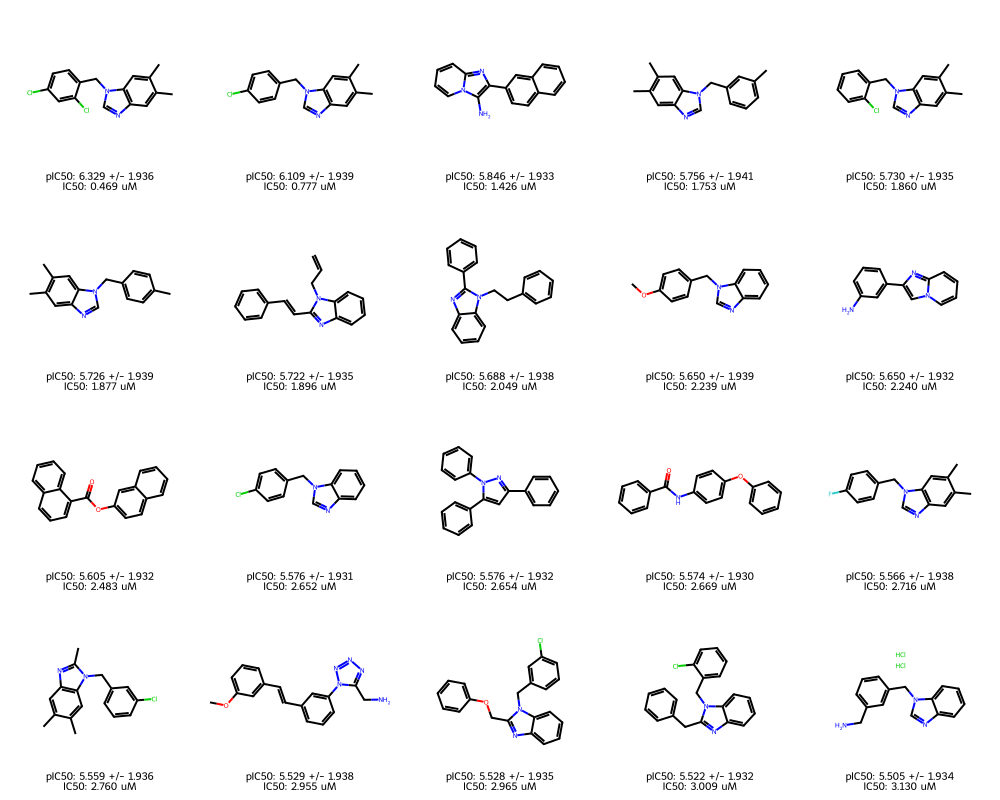

In [258]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.3f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.gif


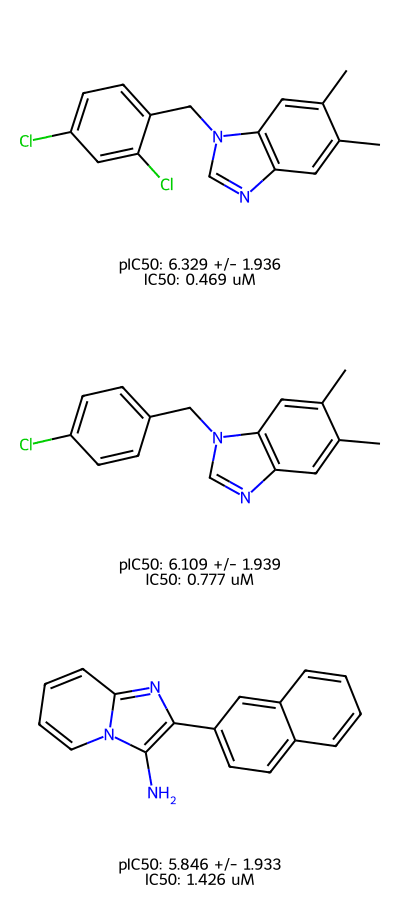

In [259]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=0,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [260]:
# Keep only the lookup columns (and drop duplicate SMILES to avoid row explosion)
lookupDF = (
    BacillusAnthracis_all_Buyable_Antibiotic[["SMILES", "source_DataBase"]]
    .dropna(subset=["SMILES"])
    .drop_duplicates(subset=["SMILES"], keep="first")
)

# Left-merge so every prediction row is preserved; source_DataBase is appended as the last column
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.merge(
    lookupDF,
    how="left",
    on="SMILES",
    validate="many_to_one"  # many predictions can map to one SMILES in lookup
)

BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20

,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,Cc1cc2ncn(Cc3ccc(Cl)cc3Cl)c2cc1C,6.329,1.936,0.469,ChemDiv_Antibiotic
1,2,Cc1cc2ncn(Cc3ccc(Cl)cc3)c2cc1C,6.109,1.939,0.777,LifeChemicals_Antibiotic
2,3,Nc1c(-c2ccc3ccccc3c2)nc2ccccn12,5.846,1.933,1.426,LifeChemicals_Antibiotic
3,4,Cc1cccc(Cn2cnc3cc(C)c(C)cc32)c1,5.756,1.941,1.753,ChemDiv_Antibiotic
4,5,Cc1cc2ncn(Cc3ccccc3Cl)c2cc1C,5.730,1.935,1.860,LifeChemicals_Antibiotic
5,6,Cc1ccc(Cn2cnc3cc(C)c(C)cc32)cc1,5.726,1.939,1.877,ChemDiv_Antibiotic
6,7,C=CCn1c(/C=C/c2ccccc2)nc2ccccc21,5.722,1.935,1.896,LifeChemicals_Antibiotic
7,8,c1ccc(CCn2c(-c3ccccc3)nc3ccccc32)cc1,5.688,1.938,2.049,LifeChemicals_Antibiotic
8,9,COc1ccc(Cn2cnc3ccccc32)cc1,5.650,1.939,2.239,LifeChemicals_Antibiotic
9,10,Nc1cccc(-c2cn3ccccc3n2)c1,5.650,1.932,2.240,LifeChemicals_Antibiotic


# <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

### All `basidalin precursor` compounds generated by `DORAnet` --> Possible `Antibiotic`

In [261]:
basidalinPrecursor_DORAnetGenerated_Antibiotic = pd.read_csv(DORANETmoleculesDataDir + "basidalinPrecursor_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(basidalinPrecursor_DORAnetGenerated_Antibiotic)} molecules")
basidalinPrecursor_DORAnetGenerated_Antibiotic['source_DataBase'] = 'basidalin_Precursor'
basidalinPrecursor_DORAnetGenerated_Antibiotic

Loaded 651812 molecules


,SMILES,Is_Starter,SourceDirectories,source_DataBase
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor
...,...,...,...,...
651807,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,starter_02053,basidalin_Precursor
651808,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,starter_02053,basidalin_Precursor
651809,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,starter_02053,basidalin_Precursor
651810,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,starter_02053,basidalin_Precursor


### Generate `MACAW` embeedings for all `DORAnet` generated molecules --> to run external validation with `ART`

In [262]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(basidalinPrecursor_DORAnetGenerated_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=basidalinPrecursor_DORAnetGenerated_Antibiotic.index)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW = pd.concat([basidalinPrecursor_DORAnetGenerated_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {basidalinPrecursor_DORAnetGenerated_Antibiotic.shape}")
print(f"New dataframe shape: {basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.csv"), index=False)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_chEMBL_MACAW_transformer.joblib
50000
100000
Partition 3/10
  Fold 3 - Train MAE: 1.20, Test MAE: 1.25
Partition 7/10
  Fold 7 - Train MAE: 1.20, Test MAE: 1.14
Partition 2/10
  Fold 2 - Train MAE: 1.21, Test MAE: 1.22
Partition 8/10
  Fold 8 - Train MAE: 1.15, Test MAE: 1.62
Partition 1/10
  Fold 1 - Train MAE: 1.12, Test MAE: 1.79
Partition 6/10
  Fold 6 - Train MAE: 1.23, Test MAE: 1.42
Partition 10/10
  Fold 10 - Train MAE: 1.22, Test MAE: 1.44
Partition 4/10
  Fold 4 - Train MAE: 1.19, Test MAE: 1.34
Partition 5/10
  Fold 5 - Train MAE: 1.18, Test MAE: 1.43
Partition 9/10
  Fold 9 - Train MAE: 1.13, Test MAE: 1.56
150000
200000
250000
300000
350000
400000
450000
500000
550000
600000
650000
MACAW embeddings shape: (651812, 60)

Original dataframe shape: (651812, 4)
New dataframe shape: (651812, 64)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW

,SMILES,Is_Starter,SourceDirectories,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.055,-0.040,0.039,0.016,-0.124,0.094,...,-0.017,0.011,0.026,0.023,-0.008,0.003,-0.010,-0.017,-0.023,0.015
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,0.023,-0.092,0.068,0.050,-0.236,0.151,...,-0.017,0.023,0.013,0.007,0.010,-0.012,-0.017,0.001,0.010,-0.007
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.225,0.037,-0.038,-0.018,-0.044,-0.021,...,0.027,-0.025,0.010,0.033,0.009,-0.020,-0.008,0.009,-0.020,-0.001
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.231,0.037,-0.038,-0.022,-0.036,-0.027,...,0.027,-0.031,0.008,0.034,0.011,-0.017,-0.011,0.014,-0.025,0.002
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,starter_00000;starter_00001;starter_00002;star...,basidalin_Precursor,-0.013,-0.055,0.054,0.034,-0.172,0.127,...,-0.031,0.015,0.024,0.017,0.002,-0.001,-0.011,-0.004,-0.018,0.011


## Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [19]:
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction

pPotency_prediction range: 1.393 → 5.178


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,3.526906,1.930244,-0.256372,7.310185,0.000297,4.895708e-08,1.804561
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,basidalin_Precursor,3.252108,1.929911,-0.530518,7.034734,0.000560,9.231371e-08,3.392489
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,basidalin_Precursor,2.689813,1.934148,-1.101116,6.480743,0.002043,3.305651e-07,12.621659
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,basidalin_Precursor,2.674573,1.935209,-1.118437,6.467584,0.002116,3.407348e-07,13.135214
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,basidalin_Precursor,3.274244,1.931984,-0.512445,7.060933,0.000532,8.690938e-08,3.254203
...,...,...,...,...,...,...,...,...,...,...
651806,C[C@H](N)CC1=C(O)C(=O)OC1=C[C@@H](C)CNC=O,False,basidalin_Precursor,2.637517,1.934402,-1.153910,6.428945,0.002304,3.724393e-07,14.253118
651807,Cc1c(O)c2oc1=C[C@@H](C)CNC(=O)[C@H](C)N=2,False,basidalin_Precursor,2.789167,1.936595,-1.006559,6.584894,0.001625,2.600796e-07,10.152172
651808,C[C@H](C=C1OC(=O)C2=C1CO2)CNC(O)[C@H](C)N,False,basidalin_Precursor,3.151059,1.937884,-0.647195,6.949312,0.000706,1.123798e-07,4.438075
651809,CC1=C2O[C@](C)(N)C(O)NC[C@H](C)C=C1OC2=O,False,basidalin_Precursor,3.136100,1.940873,-0.668012,6.940212,0.000731,1.147593e-07,4.655990


### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [20]:
predicted_pPotency = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 4.86 ± 1.96 (IC50: 13.9019 µM)
Highest predicted pPotency: 5.18 ± 1.93 (IC50: 6.6406 µM)
pPotency range of top 20 compounds: pPotency --> 4.86 ± 1.96 - 5.18 ± 1.93; IC50 --> 13.9019 - 6.6406 µM


In [21]:
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction.iloc[top_20_idx].copy()
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

output_csv = os.path.join(saveDir, "basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv")
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.to_csv(output_csv, index=False)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

 Saved results: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv
 Saved SMILES:  /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
394271,1,Nc1ccc(Nc2ccc(O)cc2)cc1,5.1780,1.9310,6.6406
362220,2,O=C1C=CC(=CC=CC=C2C=CC(=O)O2)O1,5.1650,1.9361,6.8432
362209,3,O=C1C=CC(=CC=Cc2ccccc2)O1,5.1610,1.9363,6.9035
465858,4,O=C1C=CC(=Cc2ccc([N+](=O)[O-])cc2)O1,5.0850,1.9325,8.2312
464682,5,O=Cc1ccc(C=C2C=CC(=O)O2)cc1,5.0430,1.9354,9.0588
362498,6,O=C1OC(=CC=Cc2ccccc2)C=C1O,5.0050,1.9420,9.8815
464602,7,O=CC(=C1C=CC(=O)O1)c1ccccc1,4.9910,1.9358,10.2027
464657,8,O=Cc1cccc(C=C2C=CC(=O)O2)c1,4.9820,1.9387,10.4332
397466,9,Nc1ccc(C(C=O)=C2C=CC(=O)O2)cc1,4.9760,1.9343,10.5768
460848,10,O=C1C=CC(=CC(=O)c2ccccc2)O1,4.9660,1.9379,10.8204


### Display molecules

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg


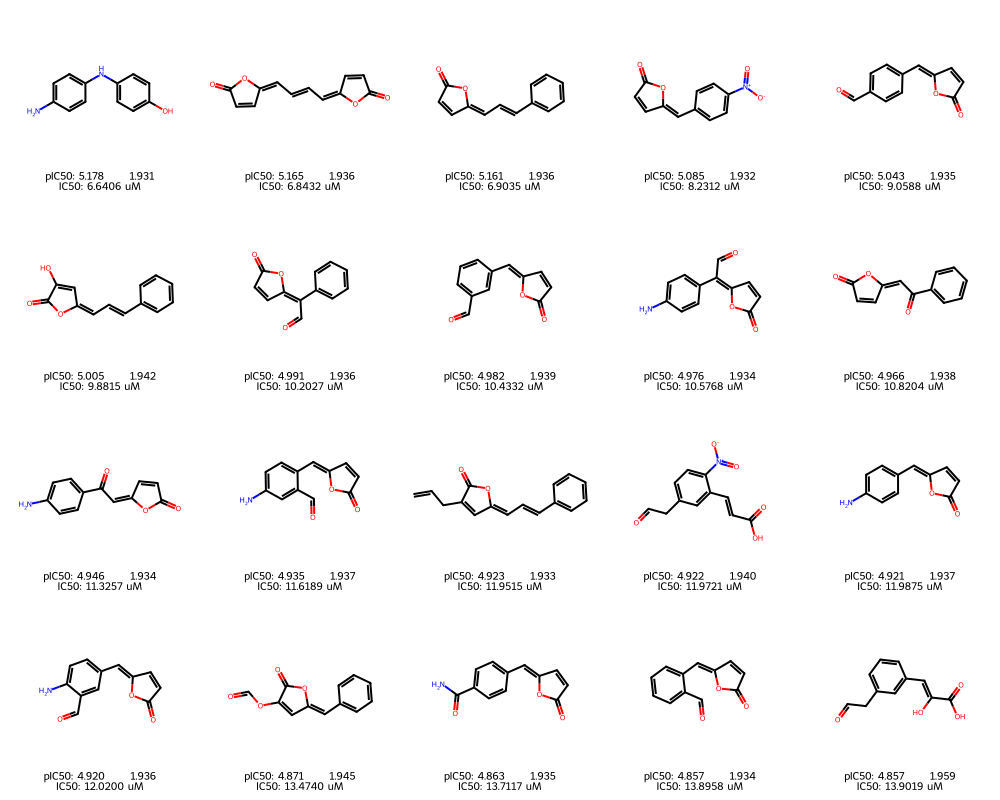

In [22]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif


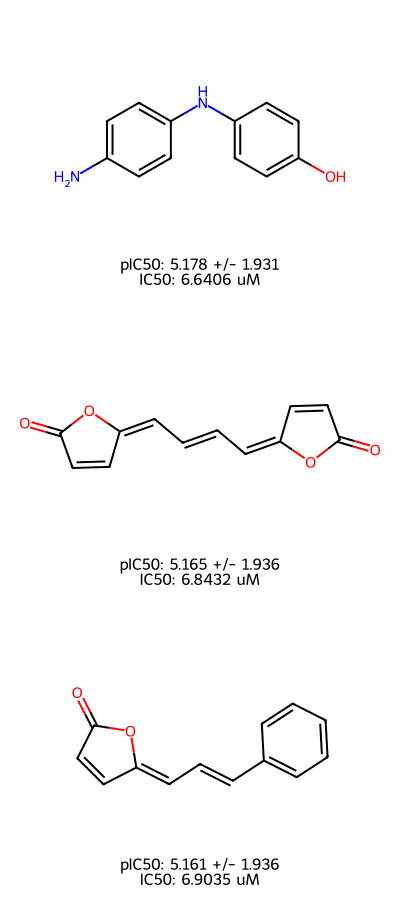

In [23]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Import all compounds generated by `DORAnet` from `Basidalin` only (gen=3) --> Possible `Antivirals`

In [26]:
BasidalinOnly_DORAnetGenerated_Antibiotic = pd.read_csv(DORANETmoleculesDataDir + "BasidalinOnly_gen3.csv", dtype=str)
print(f"Loaded {len(BasidalinOnly_DORAnetGenerated_Antibiotic)} molecules")
BasidalinOnly_DORAnetGenerated_Antibiotic['SourceDirectories'] = 'BasidalinOnly_gen3'
BasidalinOnly_DORAnetGenerated_Antibiotic

Loaded 4130 molecules


,SMILES,Is_Starter,SourceDirectories
0,C1=C(/C(=C\C=O)/OC1=O)N,True,BasidalinOnly_gen3
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,BasidalinOnly_gen3
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,BasidalinOnly_gen3
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,BasidalinOnly_gen3
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,BasidalinOnly_gen3
...,...,...,...
4125,NCC(=O)CC1(O)OC(=O)C=C1N,False,BasidalinOnly_gen3
4126,NC1=CC(O)O/C1=C/C(=O)C(N)O,False,BasidalinOnly_gen3
4127,NCC(O)/C(O)=C1/OC(=O)C=C1N,False,BasidalinOnly_gen3
4128,NCC(=O)/C(O)=C1/OC(O)C=C1N,False,BasidalinOnly_gen3


### Generate `MACAW` embeedings for all `DORAnet` generated molecules --> to run external validation with `ART`

In [27]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BasidalinOnly_DORAnetGenerated_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BasidalinOnly_DORAnetGenerated_Antibiotic.index)
BasidalinOnly_DORAnetGenerated_Antibiotic_wMACAW = pd.concat([BasidalinOnly_DORAnetGenerated_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BasidalinOnly_DORAnetGenerated_Antibiotic.shape}")
print(f"New dataframe shape: {BasidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BasidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_BasidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.csv"), index=False)
BasidalinOnly_DORAnetGenerated_Antibiotic_wMACAW.head()

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (4130, 60)

Original dataframe shape: (4130, 3)
New dataframe shape: (4130, 63)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_

,SMILES,Is_Starter,SourceDirectories,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,C1=C(/C(=C\C=O)/OC1=O)N,True,BasidalinOnly_gen3,0.0790,-0.0939,0.0289,0.0729,-0.0970,-0.0728,-0.0287,...,0.0208,-0.0266,-0.0292,-0.0120,-0.0120,-0.0269,0.0027,-0.0265,0.0365,0.0134
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,BasidalinOnly_gen3,-0.0549,-0.0401,0.0392,0.0157,-0.1235,0.0943,-0.0467,...,-0.0171,0.0111,0.0257,0.0231,-0.0076,0.0032,-0.0103,-0.0172,-0.0227,0.0149
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,BasidalinOnly_gen3,0.0225,-0.0919,0.0679,0.0502,-0.2364,0.1509,-0.0621,...,-0.0175,0.0229,0.0134,0.0074,0.0100,-0.0118,-0.0175,0.0012,0.0096,-0.0068
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,BasidalinOnly_gen3,-0.2246,0.0366,-0.0379,-0.0179,-0.0439,-0.0212,-0.0384,...,0.0271,-0.0254,0.0101,0.0331,0.0086,-0.0205,-0.0078,0.0087,-0.0196,-0.0005
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,BasidalinOnly_gen3,-0.2311,0.0373,-0.0383,-0.0224,-0.0363,-0.0267,-0.0343,...,0.0270,-0.0314,0.0076,0.0340,0.0113,-0.0168,-0.0115,0.0139,-0.0254,0.0019


## Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [28]:
BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinOnlyDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction

pPotency_prediction range: 2.413 → 4.628


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,C1=C(/C(=C\C=O)/OC1=O)N,True,BasidalinOnly_gen3,4.2148,1.9410,0.4104,8.0192,0.0001,0.0000,0.3887
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,BasidalinOnly_gen3,3.5269,1.9302,-0.2564,7.3102,0.0003,0.0000,1.8046
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,BasidalinOnly_gen3,3.2521,1.9299,-0.5305,7.0347,0.0006,0.0000,3.3925
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,BasidalinOnly_gen3,2.6898,1.9341,-1.1011,6.4807,0.0020,0.0000,12.6217
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,BasidalinOnly_gen3,2.6746,1.9352,-1.1184,6.4676,0.0021,0.0000,13.1352
...,...,...,...,...,...,...,...,...,...,...
4125,NCC(=O)CC1(O)OC(=O)C=C1N,False,BasidalinOnly_gen3,3.4879,1.9430,-0.3205,7.2962,0.0003,0.0000,2.0917
4126,NC1=CC(O)O/C1=C/C(=O)C(N)O,False,BasidalinOnly_gen3,3.9833,1.9469,0.1674,7.7992,0.0001,0.0000,0.6801
4127,NCC(O)/C(O)=C1/OC(=O)C=C1N,False,BasidalinOnly_gen3,3.1397,1.9491,-0.6806,6.9600,0.0007,0.0000,4.7931
4128,NCC(=O)/C(O)=C1/OC(O)C=C1N,False,BasidalinOnly_gen3,3.4969,1.9512,-0.3274,7.3212,0.0003,0.0000,2.1251


### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [29]:
predicted_pPotency = BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

Top 20 compounds cutoff pPotency: 4.20 ± 1.94 (IC50: 62.5855 µM)
Highest predicted pPotency: 4.63 ± 1.94 (IC50: 23.5337 µM)
pPotency range of top 20 compounds: pPotency --> 4.20 ± 1.94 - 4.63 ± 1.94; IC50 --> 62.5855 - 23.5337 µM


In [30]:
BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20 = BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction.iloc[top_20_idx].copy()
BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20 = BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20

output_csv = os.path.join(saveDir, "BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv")
BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.to_csv(output_csv, index=False)
BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20

 Saved results: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv
 Saved SMILES:  /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv


,Rank,SMILES,pPotency_prediction,pPotency_std,IC50 (µM)
3333,1,NC(=CC=O)C(=O)C(C=O)C(N)=CC=O,4.6280,1.9355,23.5337
1816,2,C=CC(=O)NC1=CC(=O)O/C1=C/C=O,4.3990,1.9413,39.8752
3332,3,NC(=CC=O)C(=O)C(C=O)C=O,4.3350,1.9357,46.1953
2649,4,NC1=CC(O)O/C1=C/C=NO,4.3270,1.9436,47.1119
3623,5,NC(=O)C=C(N)C(=O)C(C=O)C=O,4.3050,1.9348,49.5475
3177,6,Nc1cccc(O)c1,4.2830,1.9529,52.0747
3330,7,NC(=CC=O)C(C=O)=C(N)C(=O)CC=O,4.2810,1.9323,52.3776
1088,8,NC(C=CC(=O)O)=CC(=O)O,4.2630,1.9494,54.6381
3796,9,NC(=CC=O)C(N)=CC(=O)O,4.2480,1.9514,56.4706
3336,10,NC(=CC=O)C(=O)CC(=O)C(N)=CC=O,4.2370,1.9383,57.9430


### Display molecules

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg


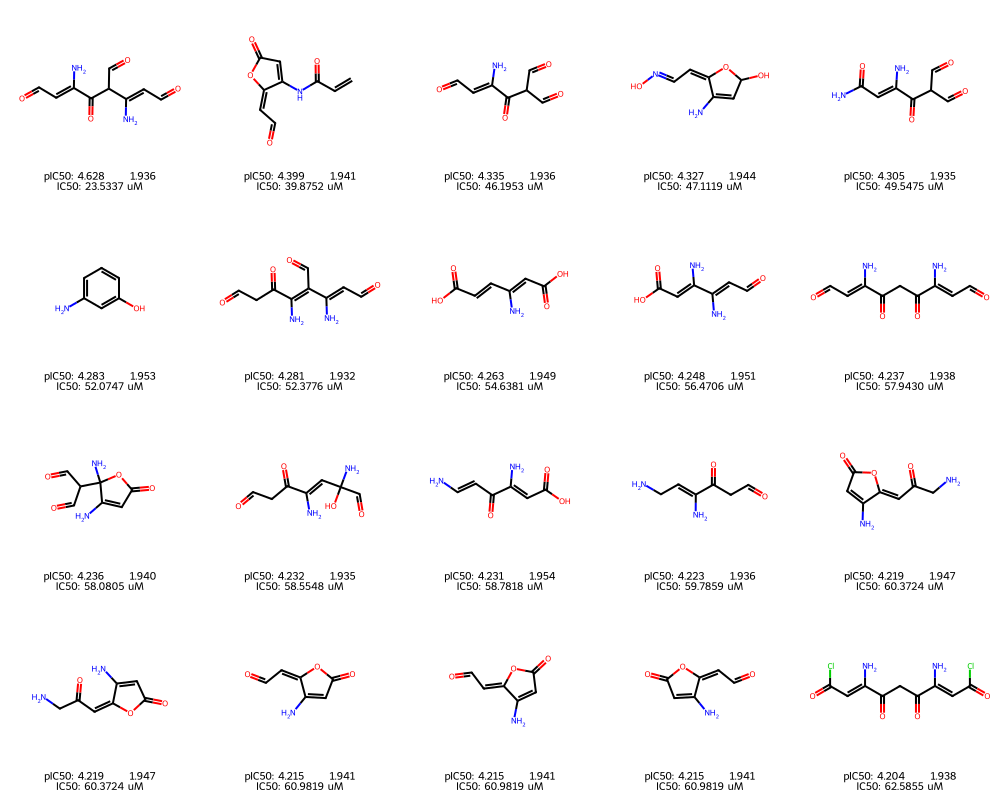

In [31]:
molecules = [Chem.MolFromSmiles(smi) for smi in BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

Saved GIF: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW/BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif


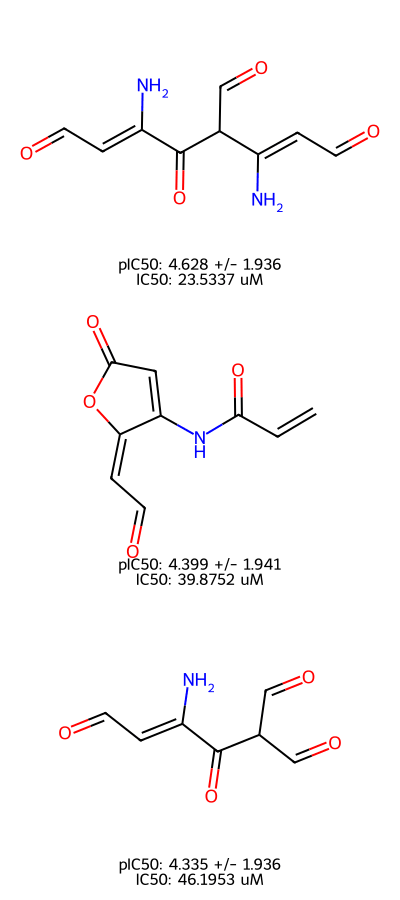

In [32]:
molecules = [Chem.MolFromSmiles(smi) for smi in BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'BasidalinOnly_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Checking drug likeliness of `Basidalin` only

In [268]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Dictionary of drugs and their SMILES
drugs = {
    'Basidalin': Basidalin_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

 Basidalin
  Formula: C6H5NO3
  MW: 139.11 g/mol
Total DTRA target compounds to screen: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Basidalin,C1=C(/C(=C\C=O)/OC1=O)N,C6H5NO3,139.1100


Generate predictions

In [269]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "BacillusAnthracis_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,C1=C(/C(=C\C=O)/OC1=O)N,0.0790,-0.0939,0.0289,0.0729,-0.0970,-0.0728,-0.0287,0.0698,0.0124,...,0.0208,-0.0266,-0.0292,-0.0120,-0.0120,-0.0269,0.0027,-0.0265,0.0365,0.0134


# Now we will remove duplicate from training data and re-train the model

In [ ]:
# Print shape before removing duplicates
print("Before removing duplicates:", BacillusAnthracisData_chEMBL.shape)

# Aggregate duplicates *within the same bacteria*
aggDF = (
    BacillusAnthracisData_chEMBL.groupby(['Smiles', 'BacteriaClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
BacillusAnthracisData_chEMBL_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'BacteriaClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'BacteriaClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", BacillusAnthracisData_chEMBL_noDuplicates.shape)

In [ ]:
duplicates = BacillusAnthracisData_chEMBL_noDuplicates.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

In [ ]:
BacillusAnthracisData_chEMBL_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_noDuplicates_MLready.csv"), index=False)

### Create MACAW embeedings to run ART

In [ ]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)


# Fit MACAW on SMILES and pPotency
mcw.fit(BacillusAnthracisData_chEMBL_noDuplicates['Smiles'], BacillusAnthracisData_chEMBL_noDuplicates['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_noDuplicates_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracisData_chEMBL_noDuplicates['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracisData_chEMBL_noDuplicates.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
BacillusAnthracisData_chEMBL_noDuplicates_wMACAW = pd.concat([BacillusAnthracisData_chEMBL_noDuplicates, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracisData_chEMBL_noDuplicates.shape}")
print(f"New dataframe shape: {BacillusAnthracisData_chEMBL_noDuplicates_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracisData_chEMBL_noDuplicates_wMACAW

In [ ]:
BacillusAnthracisData_chEMBL_noDuplicates_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_chEMBL_noDuplicates_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [ ]:
# df = BacillusAnthracisData_chEMBL
Y = BacillusAnthracisData_chEMBL_noDuplicates.pPotency
smiles = BacillusAnthracisData_chEMBL_noDuplicates.Smiles

In [ ]:
print(len(smiles))

In [ ]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [ ]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [ ]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [ ]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=300, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [ ]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True) 


print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

### Create directory to save plot

In [ ]:
save_path = saveDir + '/BacillusAnthracis_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

### ML predictions with Train + Test results

In [ ]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")

In [ ]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/BacillusAnthracis_noDuplicates_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [ ]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one Bacteria group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=300, 
    random_state=42
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)


# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/BacillusAnthracis_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
EnamineAntibioticData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibioticData.shape}")

smiles_train = BacillusAnthracisData_chEMBL_noDuplicates.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibioticData['Canonical_SMILES'] = EnamineAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibioticData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibioticData_filtered = EnamineAntibioticData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibioticData = EnamineAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibioticData.shape}")
print(f"Removed {EnamineAntibioticData.shape[0] - EnamineAntibioticData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntibioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntibioticData.head()

Load pre-trained models for very large data sets or

Generate MACAW embeddings

In [ ]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")

Predict pPotency

In [ ]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Add predictions to dataframe

In [ ]:
EnamineAntibioticData_predicted = EnamineAntibioticData.copy()
EnamineAntibioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntibioticData_predicted['IC50 (M)'] = 10 ** (-EnamineAntibioticData_predicted['pPotency_prediction'])

EnamineAntibioticData_predicted = EnamineAntibioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibioticData_predicted.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntibioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntibioticData_predicted

Let us represent the predictions of both models:

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntibioticData_final = EnamineAntibioticData.iloc[idx].copy()
EnamineAntibioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibioticData_final

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntibioticData_top20 = EnamineAntibioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntibioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntibioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntibioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("\n Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntibioticData_top20 = EnamineAntibioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibioticData_top20

In [ ]:
EnamineAntibioticData_top20.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntibioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntibioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/BacillusAnthracis_noDuplicates_enamine_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/BacillusAnthracis_noDuplicates_enamine_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.2 Discovery of new hits specific to this bacteria (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibioticData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibioticData['Canonical_SMILES'] = LCAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibioticData['Canonical_SMILES'].isin(canonical_train)
LCAntibioticData_filtered = LCAntibioticData[mask].copy()

# Remove the helper column if you don't need it
LCAntibioticData = LCAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibioticData.shape}")
print(f"Removed {LCAntibioticData_filtered.shape[0] - LCAntibioticData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntibioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntibioticData.head()

In [ ]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")

In [ ]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

In [ ]:
LCAntibioticData_predicted = LCAntibioticData.copy()
LCAntibioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntibioticData_predicted['IC50 (M)'] = 10 ** (-LCAntibioticData_predicted['pPotency_prediction'])

LCAntibioticData_predicted = LCAntibioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibioticData_predicted.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntibioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntibioticData_predicted

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validationLCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validationLCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
LCAntibioticData_final = LCAntibioticData.iloc[idx].copy()
LCAntibioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntibioticData_final = LCAntibioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntibioticData_final

### Top 20 compounds with higher pPPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntibioticData_top20 = LCAntibioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntibioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntibioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntibioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntibioticData_top20 = LCAntibioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibioticData_top20

In [ ]:
LCAntibioticData_top20.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntibioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntibioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/BacillusAnthracis_noDuplicates_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/BacillusAnthracis_noDuplicates_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.3 Discovery of new hits specific to all Bacteriaes (data source ChemDiv antibiotics)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library ("ChemDiv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiBioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiBioticData

In [ ]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")

In [ ]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

In [ ]:
ChemDivAntiBioticData_predicted = ChemDivAntiBioticData.copy()
ChemDivAntiBioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiBioticData_predicted['IC50 (M)'] = 10 ** (-ChemDivAntiBioticData_predicted['pPotency_prediction'])

ChemDivAntiBioticData_predicted = ChemDivAntiBioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)

ChemDivAntiBioticData_predicted.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiBioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiBioticData_predicted

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validationChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/BacillusAnthracis_noDuplicates_validationChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
ChemDivAntiBioticData_final = ChemDivAntiBioticData.iloc[idx].copy()
ChemDivAntiBioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiBioticData_final = ChemDivAntiBioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiBioticData_final

### Top 20 compounds with higher pPPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiBioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiBioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiBioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiBioticData_top20

In [ ]:
ChemDivAntiBioticData_top20.to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiBioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "BacillusAnthracis/BacillusAnthracis_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiBioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiBioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/BacillusAnthracis_noDuplicates_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/BacillusAnthracis_noDuplicates_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

# Train an ML model by combining `PubChem + chEMBL` data 

### Read Pubchem bioassay data for Bacillus Anthrasis Bacteria

In [310]:
BacillusAnthracisData_Pubchem = pd.read_csv(os.path.join(modelBuildingDataDir, "allBacteria_Pubchem.csv"))
# Keep only data for Bacillus_anthracis Bacteria
BacillusAnthracisData_Pubchem = BacillusAnthracisData_Pubchem[BacillusAnthracisData_Pubchem['Bacteria'] == 'Bacillus_anthracis']
BacillusAnthracisData_Pubchem

,Bacteria,compound_id,Smiles,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.0862
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9431
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.5406
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9578
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.9140
...,...,...,...,...
3477,Bacillus_anthracis,7117403,O=C(C(=O)N1CC=C(c2ccccc2)CC1)c1c[nH]c2ccccc12,4.9208
3478,Bacillus_anthracis,54595320,N#Cc1ccc(Oc2ccccc2O)c(F)c1,4.9586
3479,Bacillus_anthracis,43458374,CN(Cc1ccccc1N)C(=O)c1cc2ccccc2o1,4.3468
3480,Bacillus_anthracis,4117778,O=C(COc1ccccc1)NCCSc1c[nH]c2ccccc12,5.4685


In [311]:
# Rename columns
BacillusAnthracisData_Pubchem = BacillusAnthracisData_Pubchem.rename(
    columns={'Bacteria': 'BacteriaClassifier'})
BacillusAnthracisData_Pubchem

,BacteriaClassifier,compound_id,Smiles,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.0862
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9431
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.5406
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9578
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.9140
...,...,...,...,...
3477,Bacillus_anthracis,7117403,O=C(C(=O)N1CC=C(c2ccccc2)CC1)c1c[nH]c2ccccc12,4.9208
3478,Bacillus_anthracis,54595320,N#Cc1ccc(Oc2ccccc2O)c(F)c1,4.9586
3479,Bacillus_anthracis,43458374,CN(Cc1ccccc1N)C(=O)c1cc2ccccc2o1,4.3468
3480,Bacillus_anthracis,4117778,O=C(COc1ccccc1)NCCSc1c[nH]c2ccccc12,5.4685


In [312]:
BacillusAnthracisData_Pubchem = BacillusAnthracisData_Pubchem[
    ['compound_id', 'Smiles', 'pPotency', 'BacteriaClassifier']]
BacillusAnthracisData_Pubchem.head()

,compound_id,Smiles,pPotency,BacteriaClassifier
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.0862,Bacillus_anthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9431,Bacillus_anthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.5406,Bacillus_anthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9578,Bacillus_anthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.9140,Bacillus_anthracis


### Remove `ID` columns from left from `chEMBL` data frame

In [314]:
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL[
    ['compound_id', 'Smiles', 'pPotency', 'BacteriaClassifier']]
BacillusAnthracisData_chEMBL

,compound_id,Smiles,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.1200,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.0000,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.0000,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.0000,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.0000,Bacillus_anthracis
...,...,...,...,...
163230,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.0000,Bacillus_anthracis
163231,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.0000,Bacillus_anthracis
163232,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.0000,Bacillus_anthracis
163233,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.8000,Bacillus_anthracis


### Combine `Pubchem + chEMBL` data

In [315]:
BacillusAnthracisData_allDB = pd.concat(
    [BacillusAnthracisData_Pubchem, BacillusAnthracisData_chEMBL],
    ignore_index=True
)

BacillusAnthracisData_allDB

,compound_id,Smiles,pPotency,BacteriaClassifier
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.0862,Bacillus_anthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9431,Bacillus_anthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.5406,Bacillus_anthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9578,Bacillus_anthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.9140,Bacillus_anthracis
...,...,...,...,...
4333,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.0000,Bacillus_anthracis
4334,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.0000,Bacillus_anthracis
4335,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.0000,Bacillus_anthracis
4336,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.8000,Bacillus_anthracis


### Canonicalize the `Smiles`

In [316]:
def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

BacillusAnthracisData_allDB['Smiles'] = (
    BacillusAnthracisData_allDB['Smiles']
    .astype(str)
    .apply(canonicalize_smiles)
)
BacillusAnthracisData_allDB

,compound_id,Smiles,pPotency,BacteriaClassifier
0,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.0862,Bacillus_anthracis
1,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9431,Bacillus_anthracis
2,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.5406,Bacillus_anthracis
3,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9578,Bacillus_anthracis
4,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.9140,Bacillus_anthracis
...,...,...,...,...
4333,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.0000,Bacillus_anthracis
4334,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.0000,Bacillus_anthracis
4335,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.0000,Bacillus_anthracis
4336,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.8000,Bacillus_anthracis


### Remove `Basidalin` from training set

In [318]:
#Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Basidalin_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
BacillusAnthracisData_allDB["canonical_smiles"] = (
    BacillusAnthracisData_allDB["Smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = BacillusAnthracisData_allDB["canonical_smiles"] != remCan
BacillusAnthracisData_allDB_clean = BacillusAnthracisData_allDB[mask].copy()

print("Original shape of data frame:", len(BacillusAnthracisData_allDB))
print("After removing Basidalin:", len(BacillusAnthracisData_allDB_clean))
BacillusAnthracisData_allDB = BacillusAnthracisData_allDB_clean.copy()

Original shape of data frame: 4338
After removing Basidalin: 4338


### Add `ID` column to left; keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [319]:
BacillusAnthracisData_allDB.insert(0, 'ID', range(1, len(BacillusAnthracisData_allDB) + 1))
BacillusAnthracisData_allDB.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier,canonical_smiles
0,1,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.0862,Bacillus_anthracis,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...
1,2,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9431,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...
2,3,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.5406,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1
3,4,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9578,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...
4,5,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.9140,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [344]:
# Define bins and labels
bins = [0, 3, 10, 12, float('inf')]
labels = ['0-3', '3-10', '10-12', '> 12']

# Create categories
BacillusAnthracisData_allDB['pPotency_category'] = pd.cut(
    BacillusAnthracisData_allDB['pPotency'], 
    bins=bins, 
    labels=labels, 
    right=False  # right=False means 0 <= x < 3, 3 <= x < 10, etc.
)

# Count values per category
category_counts = BacillusAnthracisData_allDB['pPotency_category'].value_counts().sort_index()
print("pPotency Distribution:")
print(category_counts)
print(f"\nTotal: {category_counts.sum()}")

pPotency Distribution:
pPotency_category
0-3       813
3-10     3259
10-12       9
> 12        0
Name: count, dtype: int64

Total: 4081


In [320]:
print("Original shape:", BacillusAnthracisData_allDB.shape)

BacillusAnthracisData_allDB = BacillusAnthracisData_allDB[BacillusAnthracisData_allDB['pPotency'].notna() 
    & (BacillusAnthracisData_allDB['pPotency'] > 0) & (BacillusAnthracisData_allDB['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", BacillusAnthracisData_allDB.shape)

Original shape: (4338, 6)
Shape after cleaning 'pPotency' value: (4081, 6)


In [321]:
duplicates = BacillusAnthracisData_allDB.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 2434


In [322]:
BacillusAnthracisData_allDB.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_allDB_MLready.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [325]:
# df = BacillusAnthracisData_allDB
Y = BacillusAnthracisData_allDB.pPotency
smiles = BacillusAnthracisData_allDB.Smiles

In [326]:
print(len(smiles))

4081


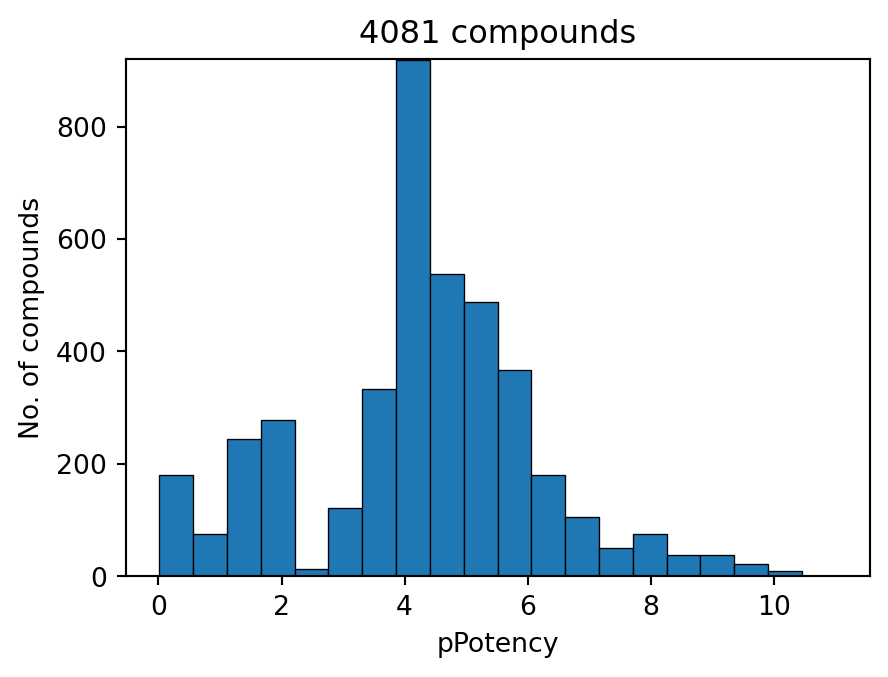

In [327]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [328]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [329]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

### Find best `MACAW` parameters

In [336]:
from copy import deepcopy
from joblib import Parallel, delayed
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def processFold(
    foldId, trainIndex, testIndex,
    smiles, Y, baseMacaw, paramGrid, numFolds
):
    print(f"Fold {foldId}/{numFolds}")

    smiTrain = smiles.iloc[trainIndex]
    smiTest  = smiles.iloc[testIndex]
    yTrain   = Y.iloc[trainIndex].values
    yTest    = Y.iloc[testIndex].values

    macawFold = deepcopy(baseMacaw)
    macawFold.fit(smiTrain, yTrain)

    XTrain = macawFold.transform(smiTrain)
    XTest  = macawFold.transform(smiTest)

    grid = GridSearchCV(SVR(), paramGrid, cv=5, refit=True)
    grid.fit(XTrain, yTrain)

    yPredTrain = grid.predict(XTrain)
    yPredTest  = grid.predict(XTest)

    return {
        "yObsTrain": yTrain,
        "yPredTrain": yPredTrain,
        "yObsTest": yTest,
        "yPredTest": yPredTest,
        "bestSvrParams": grid.best_params_,
    }


# ---- manual MACAW sweep ----
nComponentsList = [30, 45, 60, 90]      # set your limits
nLandmarksList  = [500, 750, 1000, 1250, 1500, 2000, 3000] # set your limits

numFolds = kf.get_n_splits(smiles)

macawResultsList = []

for nComponents in nComponentsList:
    for nLandmarks in nLandmarksList:

        baseMacaw = MACAW(
            type_fp="atompairs",
            metric="sokal",
            n_components=nComponents,
            n_landmarks=nLandmarks,
            random_state=42
        )

        foldResults = Parallel(n_jobs=16, verbose=10)(
            delayed(processFold)(
                foldId=i + 1,
                trainIndex=trainIdx,
                testIndex=testIdx,
                smiles=smiles,
                Y=Y,
                baseMacaw=baseMacaw,
                paramGrid=param_grid,
                numFolds=numFolds,
            )
            for i, (trainIdx, testIdx) in enumerate(kf.split(smiles))
        )

        yObsTrainAll  = np.concatenate([r["yObsTrain"] for r in foldResults])
        yPredTrainAll = np.concatenate([r["yPredTrain"] for r in foldResults])
        yObsTestAll   = np.concatenate([r["yObsTest"] for r in foldResults])
        yPredTestAll  = np.concatenate([r["yPredTest"] for r in foldResults])

        trainR2 = r2_score(yObsTrainAll, yPredTrainAll)
        testR2  = r2_score(yObsTestAll, yPredTestAll)
        gapR2   = trainR2 - testR2  # simple overfit indicator

        macawResultsList.append({
            "n_components": nComponents,
            "n_landmarks": nLandmarks,
            "trainR2": trainR2,
            "testR2": testR2,
            "gapR2": gapR2,
            "testMAE": mean_absolute_error(yObsTestAll, yPredTestAll),
            "testRMSE": np.sqrt(mean_squared_error(yObsTestAll, yPredTestAll)),
        })

        print(
            f"MACAW(n_components={nComponents}, n_landmarks={nLandmarks}) "
            f"=> Test R²={testR2:.3f}, Train R²={trainR2:.3f}, Gap={gapR2:.3f}"
        )

macawResultsDF = pd.DataFrame(macawResultsList)

# ---- Choose best generalization: max test R² ----
bestGeneralizationRow = macawResultsDF.sort_values("testR2", ascending=False).iloc[0]
print("\nBest MACAW by generalization (highest CV Test R²):")
print(bestGeneralizationRow)

MACAW(n_components=30, n_landmarks=500) => Test R²=0.566, Train R²=0.604, Gap=0.038
MACAW(n_components=30, n_landmarks=750) => Test R²=0.576, Train R²=0.616, Gap=0.040
MACAW(n_components=30, n_landmarks=1000) => Test R²=0.567, Train R²=0.605, Gap=0.038
MACAW(n_components=30, n_landmarks=1250) => Test R²=0.564, Train R²=0.608, Gap=0.045
MACAW(n_components=30, n_landmarks=1500) => Test R²=0.558, Train R²=0.589, Gap=0.032
MACAW(n_components=30, n_landmarks=2000) => Test R²=0.569, Train R²=0.609, Gap=0.040
MACAW(n_components=30, n_landmarks=3000) => Test R²=0.574, Train R²=0.613, Gap=0.039
MACAW(n_components=45, n_landmarks=500) => Test R²=0.574, Train R²=0.613, Gap=0.039
MACAW(n_components=45, n_landmarks=750) => Test R²=0.575, Train R²=0.612, Gap=0.037
MACAW(n_components=45, n_landmarks=1000) => Test R²=0.573, Train R²=0.610, Gap=0.038
MACAW(n_components=45, n_landmarks=1250) => Test R²=0.570, Train R²=0.608, Gap=0.038
MACAW(n_components=45, n_landmarks=1500) => Test R²=0.574, Train R²=0

### Run the ML model with best MACAW parameters

In [338]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=60, 
    n_landmarks=1500, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [339]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True) 


print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 4081 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [340]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.67
  RMSE: 1.18
  R²:   0.62
Test Set:
  MAE:  0.74
  RMSE: 1.24
  R²:   0.58

Best params (sample): [{'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}]
CPU times: user 1.07 s, sys: 467 ms, total: 1.53 s
Wall time: 6min 26s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW//BacillusAnthracis_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Bacillus_anthracis_bestMACAW//BacillusAnthracis_CV_TrTs.png


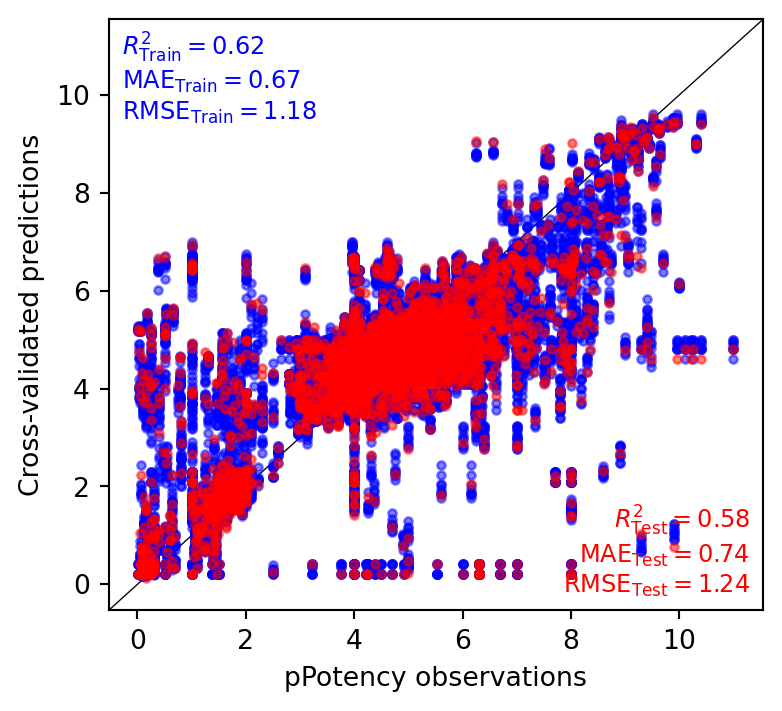

Partition 4/10
  Fold 4 - Train MAE: 0.66, Test MAE: 0.75
Partition 6/10
  Fold 6 - Train MAE: 0.66, Test MAE: 0.74
Partition 2/10
  Fold 2 - Train MAE: 0.69, Test MAE: 0.70
Partition 5/10
  Fold 5 - Train MAE: 0.66, Test MAE: 0.66
Partition 1/10
  Fold 1 - Train MAE: 0.69, Test MAE: 0.71
Partition 7/10
  Fold 7 - Train MAE: 0.65, Test MAE: 0.73
Partition 9/10
  Fold 9 - Train MAE: 0.68, Test MAE: 0.77
Partition 3/10
  Fold 3 - Train MAE: 0.65, Test MAE: 0.82
Partition 8/10
  Fold 8 - Train MAE: 0.69, Test MAE: 0.79
Partition 10/10
  Fold 10 - Train MAE: 0.66, Test MAE: 0.71


In [341]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/BacillusAnthracis_CV_TrTs.svg',
            save_formats=['svg', 'png'])

### Create MACAW embeedings to run ART

In [342]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=60, 
    n_landmarks=1500, 
    random_state=42
)


# Fit MACAW on SMILES and pPotency
mcw.fit(BacillusAnthracisData_allDB['Smiles'], BacillusAnthracisData_allDB['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracisData_allDB['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracisData_allDB.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
BacillusAnthracisData_allDB_wMACAW = pd.concat([BacillusAnthracisData_allDB, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracisData_allDB.shape}")
print(f"New dataframe shape: {BacillusAnthracisData_allDB_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracisData_allDB_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/BacillusAnthracisData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (4081, 60)

Original dataframe shape: (4081, 6)
New dataframe shape: (4081, 66)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 'MACAW_58', 'MACAW_59', 'MACAW_60']

,ID,compound_id,Smiles,pPotency,BacteriaClassifier,canonical_smiles,MACAW_1,MACAW_2,MACAW_3,MACAW_4,...,MACAW_51,MACAW_52,MACAW_53,MACAW_54,MACAW_55,MACAW_56,MACAW_57,MACAW_58,MACAW_59,MACAW_60
0,1,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.0862,Bacillus_anthracis,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,-0.0962,0.0332,-0.0218,0.0775,...,0.0122,0.0054,0.0015,-0.0517,0.0163,0.0258,0.0084,-0.0072,0.0534,0.0035
1,2,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9431,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,-0.1661,0.1802,0.0170,-0.0108,...,-0.0489,0.0276,-0.0683,-0.0377,0.0119,-0.0837,-0.0479,0.0070,-0.0051,0.0037
2,3,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.5406,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,-0.0999,0.1535,-0.0596,0.0469,...,-0.0801,-0.0566,0.0852,-0.0251,0.0066,0.0149,-0.0013,-0.0632,0.0317,-0.0582
3,4,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.9578,Bacillus_anthracis,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,-0.1661,0.1802,0.0170,-0.0108,...,-0.0489,0.0276,-0.0683,-0.0377,0.0119,-0.0837,-0.0479,0.0070,-0.0051,0.0037
4,5,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.9140,Bacillus_anthracis,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,-0.0999,0.1535,-0.0596,0.0469,...,-0.0801,-0.0566,0.0852,-0.0251,0.0066,0.0149,-0.0013,-0.0632,0.0317,-0.0582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4330,4331,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.2676,Bacillus_anthracis,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,-0.2176,0.0194,0.0841,0.1444,...,0.0528,-0.0056,0.1091,0.0300,0.0421,-0.0088,0.0106,0.0098,-0.0047,0.0544
4332,4333,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.0223,Bacillus_anthracis,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,-0.0195,0.0708,0.0258,0.0508,...,0.0069,-0.0266,0.0393,0.0389,-0.0675,-0.0507,0.0016,-0.0587,-0.0764,0.0174
4333,4334,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.0000,Bacillus_anthracis,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,0.0797,0.1236,-0.0501,0.0262,...,-0.0429,-0.0395,-0.0127,0.0019,0.0754,-0.0331,0.0078,0.0541,-0.0541,-0.0477
4336,4337,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.8000,Bacillus_anthracis,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,-0.0045,0.1921,-0.0168,-0.0349,...,0.0070,-0.0052,-0.0658,-0.0012,0.0284,0.0208,-0.0434,-0.0531,0.0602,0.0052


In [343]:
BacillusAnthracisData_allDB_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_allDB_wMACAW.csv"), index=False)

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

### Create a list of data frames of all buyable antibiotic

In [ ]:
EnamineAntibioticData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibioticData.shape}")

smiles_train = BacillusAnthracisData_allDB.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibioticData['Canonical_SMILES'] = EnamineAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibioticData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibioticData_filtered = EnamineAntibioticData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibioticData = EnamineAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibioticData.shape}")
print(f"Removed {EnamineAntibioticData_filtered.shape[0] - EnamineAntibioticData.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntibioticData.SMILES
EnamineAntibioticData['source_DataBase'] = 'Enamine_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
EnamineAntibioticData = EnamineAntibioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntibioticData.head()

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibioticData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibioticData['Canonical_SMILES'] = LCAntibioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibioticData['Canonical_SMILES'].isin(canonical_train)
LCAntibioticData_filtered = LCAntibioticData[mask].copy()

# Remove the helper column if you don't need it
LCAntibioticData = LCAntibioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibioticData.shape}")
print(f"Removed {LCAntibioticData_filtered.shape[0] - LCAntibioticData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntibioticData = LCAntibioticData.SMILES
LCAntibioticData['source_DataBase'] = 'LifeChemicals_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
LCAntibioticData = LCAntibioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_LCAntibioticData)}")
LCAntibioticData.head()

In [ ]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiBioticData = ChemDivAntiBioticData.SMILES
ChemDivAntiBioticData['source_DataBase'] = 'ChemDiv_Antibiotic'
needed_cols = ['SMILES', 'source_DataBase']
ChemDivAntiBioticData = ChemDivAntiBioticData[needed_cols]

print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiBioticData)}")
ChemDivAntiBioticData

In [ ]:
%%time

# Concatenate in chunks and free memory 
DF_list = [
    EnamineAntibioticData,
    LCAntibioticData,
    ChemDivAntiBioticData,
]

BacillusAnthracis_all_Buyable_Antibiotic = pd.concat(DF_list, ignore_index=True)

# Free memory from individual dataframes
del EnamineAntibioticData
del LCAntibioticData
del ChemDivAntiBioticData
gc.collect()

print(f"Total molecules before deduplication: {len(BacillusAnthracis_all_Buyable_Antibiotic)}")

# Batch canonicalize SMILES using vectorized approach
def canonicalize_smiles_batch(smiles_series, batch_size=50000):
    results = []
    for i in range(0, len(smiles_series), batch_size):
        batch = smiles_series.iloc[i:i + batch_size]
        canonical = []
        for smi in batch:
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    canonical.append(Chem.MolToSmiles(mol))
                else:
                    canonical.append(None)
            except:
                canonical.append(None)
        results.extend(canonical)
        print(f"  Processed {min(i + batch_size, len(smiles_series))}/{len(smiles_series)} SMILES...")
        gc.collect()
    return results

print("Canonicalizing SMILES...")
BacillusAnthracis_all_Buyable_Antibiotic['SMILES'] = canonicalize_smiles_batch(BacillusAnthracis_all_Buyable_Antibiotic['SMILES'])

# Drop invalid and duplicate SMILES
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.dropna(subset=['SMILES'])
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.drop_duplicates(subset='SMILES', keep='first')
BacillusAnthracis_all_Buyable_Antibiotic = BacillusAnthracis_all_Buyable_Antibiotic.reset_index(drop=True)
gc.collect()

print(f"Total molecules after deduplication: {len(BacillusAnthracis_all_Buyable_Antibiotic)}")

# Save to a file path string
output_path = saveDir + "BacillusAnthracis_all_Buyable_Antibiotic.csv"
BacillusAnthracis_all_Buyable_Antibiotic.to_csv(output_path, index=False, encoding="utf-8")
print(f"Saved to {output_path}")

BacillusAnthracis_all_Buyable_Antibiotic

### Generate `MACAW` embeedings for all buyable molecules --> to run external validation with `ART`

In [ ]:
# ---------------------------
# 1. LOAD MACAW TRANSFORMER AND GENERATE EMBEDDINGS
# ---------------------------
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracis_all_Buyable_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracis_all_Buyable_Antibiotic.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW = pd.concat([BacillusAnthracis_all_Buyable_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracis_all_Buyable_Antibiotic.shape}")
print(f"New dataframe shape: {BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.csv"), index=False)
BacillusAnthracis_all_Buyable_Antibiotic_wMACAW.head()

### Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_wART_EnamineDataset_predicted_all.csv')
max_val = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction

### Extract `pPotency` predictions

In [ ]:
predicted_pPotency = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction['pPotency_prediction'].values

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]   # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Create dataframe with top 20
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)

# Add IC50 column in micromolar (µM)
# IC50 (µM) = 10^(-pPotency) * 1e6
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6

# Add rank column at the beginning
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = predicted_pPotency[top_20_idx[0]]   # Highest (best)
pPotency_min = predicted_pPotency[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min_uM = 10**(-pPotency_max) * 1e6            # Lowest IC50 (most potent)
IC50_max_uM = 10**(-pPotency_min) * 1e6            # Highest IC50 (least potent in top 20)

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max_uM:.3f} µM")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min_uM:.3f} µM")

print("\nRange for Top 20 Compounds:")
print(f"pPotency Range:   {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"IC50 Range (µM):  {IC50_max_uM:.3f} - {IC50_min_uM:.3f}")

# Set pandas display options
pd.options.display.float_format = lambda x: f'{x:.3f}'

# Display the dataframe
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20

In [ ]:
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.to_csv(os.path.join(saveDir + "BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.csv"), index=False)
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(os.path.join(saveDir + "BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_SMILESonly.csv"), index=False)

In [ ]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.3f} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)

### Save molecules as .gif

In [ ]:
# Get molecules and legends
molecules = [Chem.MolFromSmiles(smi) for smi in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.3f} uM"
    legends.append(legend)

# Split molecules into chunks of 4 for each frame
mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]
    
    # Generate grid image: 1 column (vertical layout), 4 rows
    frame_img = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,  # 1 per row = vertical arrangement
        useSVG=False,
        legends=chunk_legends,
        returnPNG=False
    )
    
    # Convert to RGB if necessary (GIF requires consistent mode)
    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')
    
    frames.append(frame_img)

# Save as GIF
output_gif = saveDir + 'BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,  # 3 seconds per frame
    loop=0,         # 0 = infinite loop
    optimize=True
)
print(f"Saved GIF: {output_gif}")

# Display in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# Keep only the lookup columns (and drop duplicate SMILES to avoid row explosion)
lookupDF = (
    BacillusAnthracis_all_Buyable_Antibiotic[["SMILES", "source_DataBase"]]
    .dropna(subset=["SMILES"])
    .drop_duplicates(subset=["SMILES"], keep="first")
)

# Left-merge so every prediction row is preserved; source_DataBase is appended as the last column
BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20 = BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20.merge(
    lookupDF,
    how="left",
    on="SMILES",
    validate="many_to_one"  # many predictions can map to one SMILES in lookup
)

BacillusAnthracis_all_Buyable_Antibiotic_wARTprediction_top20

# <span style="color: #1e88e5;">Load <code>DORANET</code> generated molecules data</span>

### All `basidalin precursor` compounds generated by `DORAnet` --> Possible `Antibiotic`

In [ ]:
basidalinPrecursor_DORAnetGenerated_Antibiotic = pd.read_csv(DORANETmoleculesDataDir + "basidalinPrecursor_DORAnetGeneratedMolecules.csv", dtype=str)
print(f"Loaded {len(basidalinPrecursor_DORAnetGenerated_Antibiotic)} molecules")
basidalinPrecursor_DORAnetGenerated_Antibiotic['source_DataBase'] = 'basidalin_Precursor'
basidalinPrecursor_DORAnetGenerated_Antibiotic

### Generate `MACAW` embeedings for all `DORAnet` generated molecules --> to run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(modelBuildingDataDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(basidalinPrecursor_DORAnetGenerated_Antibiotic['SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=basidalinPrecursor_DORAnetGenerated_Antibiotic.index)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW = pd.concat([basidalinPrecursor_DORAnetGenerated_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {basidalinPrecursor_DORAnetGenerated_Antibiotic.shape}")
print(f"New dataframe shape: {basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "BacillusAnthracisData_basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.csv"), index=False)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.head()

## Read results (`SMILES` & `Ppotency`) from `ART` post predictions with uncertentity

In [ ]:
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction = pd.read_csv(ARTresultsDir + 'BacillusAnthracis_BasidalinPrecursorDORAnetGenerated_Antibiotic_ARTprediction.csv')
max_val = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].max()
min_val = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction

### Filter out `top 20` compounds with higher `pPotency` from all `DORAnet` generated molecules

In [ ]:
predicted_pPotency = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_prediction'].values
predicted_pPotency_std = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction['pPotency_std'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]
highest_pPotency = predicted_pPotency[top_20_idx[0]]
cutoff_std = predicted_pPotency_std[top_20_idx[-1]]
highest_std = predicted_pPotency_std[top_20_idx[0]]
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM = 10**(-highest_pPotency) * 1e6

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} ± {cutoff_std:.2f} (IC50: {cutoff_IC50_uM:.4f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} ± {highest_std:.2f} (IC50: {best_IC50_uM:.4f} µM)")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} ± {cutoff_std:.2f} - {highest_pPotency:.2f} ± {highest_std:.2f}; IC50 --> {cutoff_IC50_uM:.4f} - {best_IC50_uM:.4f} µM")

In [ ]:
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction.iloc[top_20_idx].copy()
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20['pPotency_prediction'] = predicted_pPotency[top_20_idx].round(3)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20['IC50 (µM)'] = 10**(-predicted_pPotency[top_20_idx]) * 1e6
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.insert(0, 'Rank', range(1, 21))

pd.options.display.float_format = lambda x: f'{x:.4f}'

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"]
)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

output_csv = os.path.join(saveDir, "basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv")
output_smiles_csv = os.path.join(saveDir, "basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv")
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.to_csv(output_csv, index=False)
basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[['SMILES']].to_csv(output_smiles_csv, index=False)
print(f" Saved results: {output_csv}")
print(f" Saved SMILES:  {output_smiles_csv}")

basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

### Display molecules

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} ± {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

img = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=False, legends=legends, returnPNG=False
)

output_png = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

svg = Draw.MolsToGridImage(
    molecules, subImgSize=(200, 200), molsPerRow=5,
    useSVG=True, legends=legends
)

output_svg = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")

display(img)

### Display molecules in `.gif`

In [ ]:
molecules = [Chem.MolFromSmiles(smi) for smi in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.SMILES[:50]]

legends = []
for idx, row in basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (µM)']:.4f} uM"
    legends.append(legend)

mols_per_frame = 3
frames = []

for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    frame_img = Draw.MolsToGridImage(
        chunk_mols, subImgSize=(400, 300), molsPerRow=1,
        useSVG=False, legends=chunk_legends, returnPNG=False
    )

    if frame_img.mode != 'RGB':
        frame_img = frame_img.convert('RGB')

    frames.append(frame_img)

output_gif = saveDir + 'basidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.gif'
frames[0].save(
    output_gif, save_all=True, append_images=frames[1:],
    duration=3000, loop=2, optimize=True
)
print(f"Saved GIF: {output_gif}")

from IPython.display import display, Image as IPImage
display(IPImage(filename=output_gif))

### Checking drug likeliness of `Basidalin` only

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Dictionary of drugs and their SMILES
drugs = {
    'Basidalin': Basidalin_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

Generate predictions

In [ ]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "BacillusAnthracis_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets